## **1. Dataset**

- DBpedia 14 (Hugging Face)
    - Contains 560,000 Wikipedia articles
    - Categorized into 14 categories
    - Each article includes:
        - Title: The title of the Wikipedia article.
        - Content: The text content from the Wikipedia article.

- Categories: Company, EducationalInstitution, Artist, Athlete, OfficeHolder, and more.



In [2]:
# general
import os
import string
import random
import pandas as pd
from IPython.display import display, HTML
from collections import Counter, defaultdict

# dataset
from datasets import load_dataset

from sklearn.model_selection import train_test_split

- The following code loads the **DBPedia 14** dataset and preprocesses it for training a transformer model. Due to the high computational cost associated with training transformers, we **downsample** the dataset as follows:
  - **2000 samples per category for training**
  - **1000 samples per category for testing**


### **Steps in the Code**  
1. **Load the DBPedia dataset** using `load_dataset("dbpedia_14")`.  
2. **Extract category labels** and display dataset features.  
3. **Downsample the dataset** to balance classes and reduce training time.  
4. **Split the test set into validation and test sets** (50% each).  
5. **Convert data into Hugging Face `DatasetDict` format** for compatibility with `transformers`.  


In [3]:
def load_db():
    dataset = load_dataset("dbpedia_14")
    dp_train = dataset["train"]
    dp_test = dataset["test"]
    categories = dp_train.features['label'].names

     # Print the features to understand the structure
    print("Features:", dp_train.features)
    print("Categories:", categories)
    print()
    print()

    data = []
    for i in range(2):
        label_index = dp_train[i]['label']
        data.append([dp_train[i]['title'], dp_train[i]['content'][:500], categories[label_index]])

    df = pd.DataFrame(data, columns=["Title", "Content", "Category"])

    # Convert DataFrame to scrollable HTML table
    html_table = df.to_html(index=False)

    # Wrap in a div with CSS to make it scrollable
    scrollable_html = f"""
    <div style="width:100%; overflow-x:auto; white-space:nowrap;">
        {html_table}
    </div>
    """
    display(HTML(scrollable_html))

    return dp_train, dp_test, categories

train_data, test_data, categories = load_db()

samples_per_category_train = 2000 # Train set
samples_per_category_test = 1000  # Test set

# Function to downsample a dataset
def downsample(X, y, samples_per_category):
    label_to_samples = defaultdict(list)

    # Group samples by label
    for text, label in zip(X, y):
        label_to_samples[label].append(text)

    # Sample from each category
    X_downsampled, y_downsampled = [], []
    for label, texts in label_to_samples.items():
        sampled_texts = random.sample(texts, min(samples_per_category, len(texts)))  # Avoid errors if a category has fewer samples
        X_downsampled.extend(sampled_texts)
        y_downsampled.extend([label] * len(sampled_texts))

    return X_downsampled, y_downsampled

# Apply downsampling
X_train_downsampled, y_train_downsampled = downsample(train_data['content'], train_data['label'], samples_per_category_train) # X: content , y: labels
X_test_downsampled, y_test_downsampled = downsample(test_data['content'], test_data['label'], samples_per_category_test)

print()

# Count occurrences in each split
train_counts = Counter(train_data['label'])
test_counts = Counter(test_data['label'])
df_counts = pd.DataFrame({"Train": train_counts, "Test": test_counts}).T
print("Count occurrences of each label in the initial training  & test set:")
print(df_counts)

print()

print("Count occurrences of each label in the downsampled training & test set:")
# Count occurrences of each label in the downsampled training set
train_label_counts = Counter(y_train_downsampled)
test_label_counts = Counter(y_test_downsampled)
df_counts_downsampled = pd.DataFrame({"Train": train_label_counts, "Test": test_label_counts}).T
print(df_counts_downsampled)

X_test, X_val, y_test, y_val = train_test_split(
    X_test_downsampled, y_test_downsampled,
    test_size=0.5, stratify=y_test_downsampled, random_state=42
)
X_train =   X_train_downsampled
y_train = y_train_downsampled
print()
print("Count occurrences of each label after splitting test set to validation and test sets")
# Count occurrences of each label
train_label_counts = Counter(y_train_downsampled)
val_label_counts = Counter(y_val)
test_label_counts = Counter(y_test)
df_counts_downsampled = pd.DataFrame({"Train": train_label_counts, "Validation": val_label_counts, "Test": test_label_counts}).T
print(df_counts_downsampled)

from datasets import Dataset, DatasetDict

# Combine into a DatasetDict
train_data = {"text": X_train, "label": y_train}
val_data = {"text": X_val, "label": y_val}
test_data = {"text": X_test, "label": y_test}

train_dataset = Dataset.from_dict(train_data)
val_dataset = Dataset.from_dict(val_data)
test_dataset = Dataset.from_dict(test_data)

# Create DatasetDict (with train, val, test splits)
dataset = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
})

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.64k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/106M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/13.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/70000 [00:00<?, ? examples/s]

Features: {'label': ClassLabel(names=['Company', 'EducationalInstitution', 'Artist', 'Athlete', 'OfficeHolder', 'MeanOfTransportation', 'Building', 'NaturalPlace', 'Village', 'Animal', 'Plant', 'Album', 'Film', 'WrittenWork'], id=None), 'title': Value(dtype='string', id=None), 'content': Value(dtype='string', id=None)}
Categories: ['Company', 'EducationalInstitution', 'Artist', 'Athlete', 'OfficeHolder', 'MeanOfTransportation', 'Building', 'NaturalPlace', 'Village', 'Animal', 'Plant', 'Album', 'Film', 'WrittenWork']




Title,Content,Category
E. D. Abbott Ltd,Abbott of Farnham E D Abbott Limited was a British coachbuilding business based in Farnham Surrey trading under that name from 1929. A major part of their output was under sub-contract to motor vehicle manufacturers. Their business closed in 1972.,Company
Schwan-Stabilo,Schwan-STABILO is a German maker of pens for writing colouring and cosmetics as well as markers and highlighters for office use. It is the world's largest manufacturer of highlighter pens Stabilo Boss.,Company



Count occurrences of each label in the initial training  & test set:
          0      1      2      3      4      5      6      7      8      9   \
Train  40000  40000  40000  40000  40000  40000  40000  40000  40000  40000   
Test    5000   5000   5000   5000   5000   5000   5000   5000   5000   5000   

          10     11     12     13  
Train  40000  40000  40000  40000  
Test    5000   5000   5000   5000  

Count occurrences of each label in the downsampled training & test set:
         0     1     2     3     4     5     6     7     8     9     10    11  \
Train  2000  2000  2000  2000  2000  2000  2000  2000  2000  2000  2000  2000   
Test   1000  1000  1000  1000  1000  1000  1000  1000  1000  1000  1000  1000   

         12    13  
Train  2000  2000  
Test   1000  1000  

Count occurrences of each label after splitting test set to validation and test sets
              0     1     2     3     4     5     6     7     8     9     10  \
Train       2000  2000  2000  2000  2000 

In [4]:
import torch
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

cuda


**Tokenization of the dataset using:**

- **Tokenizer**: Uses `distilroberta-base` from Hugging Face.
- **Truncation**: Ensures sequences do not exceed **512 tokens**.
- **Padding**: Pads sequences dynamically to the longest sequence in each batch (instead of a fixed length).
- **Batch Processing**: Uses `map()` for efficient tokenization across the dataset.



In [18]:
import transformers
from functools import partial

# Initialize tokenizer
tokenizer = transformers.AutoTokenizer.from_pretrained("distilroberta-base")

# Define the preprocessing function
def prepare_dataset(examples, tokenizer):
    # Pad only the shortest sequences to match the longest one in the batch, instead of padding all sequences to max_length=512
    return tokenizer(examples['text'], truncation=True, padding=True, max_length=512, return_tensors="pt")

# Apply the tokenizer using map
tokenized_dataset = dataset.map(partial(prepare_dataset, tokenizer=tokenizer), batched=True)

# Check the first tokenized example from the train split
print(tokenized_dataset['train'][0])

Map:   0%|          | 0/28000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

{'text': ' Osseon Therapeutics Inc. designs medical devices to treat degenerative bone and joint disease. Based in Santa Rosa California the company develops and manufactures devices to treat compression fractures of the thoracic and lumbar vertebral spine.', 'label': 0, 'input_ids': [0, 4838, 1090, 261, 7135, 5776, 10381, 603, 4, 7191, 1131, 2110, 7, 3951, 27462, 3693, 9013, 8, 2660, 2199, 4, 7253, 11, 2005, 14290, 886, 5, 138, 12626, 8, 17611, 2110, 7, 3951, 26640, 28456, 9, 5, 43500, 1043, 636, 8, 784, 4179, 271, 32969, 44283, 20625, 4, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

- This code sets up a **DistilRoBERTa-based** sequence classification model for the **DBPedia 14** dataset:


In [19]:
# Create label mappings
id2label = {i: label for i, label in enumerate(categories)}
label2id = {label: i for i, label in enumerate(categories)}

# Load model with DBPedia 14 labels
model = transformers.AutoModelForSequenceClassification.from_pretrained(
    "distilroberta-base",
    num_labels=14,
    id2label=id2label,
    label2id=label2id
)

# Count model parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Print parameter details
print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 82129166
Trainable parameters: 82129166


In [ ]:
model

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
           

In [8]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [9]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_metrics(trainer):
    log_history = trainer.state.log_history

    train_epochs, train_loss, train_accuracy, train_f1 = [], [], [], []
    eval_metrics = {}  # Store evaluation metrics per epoch

    for log in log_history:
        epoch = log.get("epoch")
        if epoch is None:
            continue  # Skip logs without an epoch

        # Collect train loss from logs containing "loss" key
        if "loss" in log:
            if epoch not in train_epochs:  # Add loss only once per epoch
                train_epochs.append(epoch)
                train_loss.append(log["loss"])

        # Collect train accuracy and F1 from logs containing "train_accuracy" and "train_f1"
        if "train_accuracy" in log and "train_f1" in log:
            train_accuracy.append(log["train_accuracy"])
            train_f1.append(log["train_f1"])

        # Collect evaluation metrics (loss, accuracy, f1)
        if "eval_loss" in log or "eval_accuracy" in log or "eval_f1" in log:
            eval_metrics[epoch] = {k: log[k] for k in ["eval_loss", "eval_accuracy", "eval_f1"] if k in log}

    # Convert to numpy arrays for plotting
    train_epochs = np.array(train_epochs)
    train_loss = np.array(train_loss)
    train_accuracy = np.array(train_accuracy)
    train_f1 = np.array(train_f1)

    # Ensure evaluation metrics align correctly
    eval_epochs = sorted(eval_metrics.keys())
    eval_loss = np.array([eval_metrics[e].get("eval_loss", None) for e in eval_epochs])
    eval_accuracy = np.array([eval_metrics[e].get("eval_accuracy", None) for e in eval_epochs])
    eval_f1 = np.array([eval_metrics[e].get("eval_f1", None) for e in eval_epochs])

    # Align training arrays to the same size
    min_len = min(len(train_epochs), len(train_loss), len(train_accuracy), len(train_f1))
    train_epochs, train_loss = train_epochs[:min_len], train_loss[:min_len]
    train_accuracy, train_f1 = train_accuracy[:min_len], train_f1[:min_len]

    # Plot the results
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Training and Evaluation Metrics", fontsize=16, fontweight="bold")

    # Loss Plot
    axes[0].plot(train_epochs, train_loss, label="Train Loss", marker="o", color="blue")
    axes[0].plot(eval_epochs, eval_loss, label="Eval Loss", marker="s", color="red")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    # Accuracy Plot
    axes[1].plot(train_epochs, train_accuracy, label="Train Accuracy", marker="o", color="blue")
    axes[1].plot(eval_epochs, eval_accuracy, label="Eval Accuracy", marker="s", color="red")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    # F1 Score Plot
    axes[2].plot(train_epochs, train_f1, label="Train F1", marker="o", color="blue")
    axes[2].plot(eval_epochs, eval_f1, label="Eval F1", marker="s", color="red")
    axes[2].set_title("F1 Score")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("F1 Score")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()


In [12]:
import time
from transformers import Trainer
from typing import Optional, List, Dict
from datasets import Dataset
import torch
import transformers
from transformers import TrainerCallback, EarlyStoppingCallback, Trainer
import evaluate
import numpy as np
from copy import deepcopy
import os

## Custom Training Callback for Evaluation

Below code defines a **custom callback** for the `Trainer` class to enhance **logging and evaluation**:

- **Class: `CustomCallback(TrainerCallback)`**
  - Inherits from **Hugging Face's TrainerCallback**.
  - Designed to perform additional evaluations at the **end of each epoch**.

- **Functionality:**
  - **On epoch end (`on_epoch_end`)**:
    - If evaluation is scheduled, it **copies the control state** to avoid unwanted modifications.
    - **Evaluates on the training dataset**:
      - Logs the **training loss and metrics** for better monitoring.
    - **Evaluates on the validation dataset**:
      - Ensures that `eval_loss` is logged, even if missing from results.
    - Logs both training and validation results.


In [ ]:
# Custom Callback
class CustomCallback(TrainerCallback):

    def __init__(self, trainer) -> None:
        super().__init__()
        self._trainer = trainer

    def on_epoch_end(self, args, state, control, **kwargs):
        if control.should_evaluate:
            control_copy = deepcopy(control)

            # Evaluate on training dataset
            train_results = self._trainer.evaluate(
                eval_dataset=self._trainer.train_dataset,
                metric_key_prefix="train"
            )
            self._trainer.log(train_results)  # Ensure logging happens

            # Evaluate on validation dataset
            eval_results = self._trainer.evaluate(metric_key_prefix="eval")
            if "eval_loss" not in eval_results:
                eval_results["eval_loss"] = train_results.get("train_loss", None)
            self._trainer.log(eval_results)  # Ensure logging happens

            return control_copy  # Ensure control updates

data_collator = transformers.DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")



def compute_metrics(p):
    accuracy_metric = evaluate.load("accuracy")
    f1_metric = evaluate.load("f1")

    predictions, labels = p

    # Convert to NumPy array before tensor conversion
    if isinstance(predictions, torch.Tensor):
        predictions = predictions.numpy()

    if isinstance(labels, torch.Tensor):
        labels = labels.numpy()

    # Convert logits to predicted class indices
    predictions = np.argmax(predictions, axis=1)

    # Compute metrics
    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")

    return {
        "accuracy": accuracy["accuracy"],
        "f1": f1["f1"]
    }

- weight decay

In [ ]:
from transformers import EarlyStoppingCallback

training_args = transformers.TrainingArguments(
    num_train_epochs=20,
    per_device_train_batch_size=32,
    gradient_accumulation_steps=16,
    fp16=True,
    weight_decay=0.1,
    learning_rate=1e-5,
    logging_strategy="epoch",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    output_dir="outputs",
    optim="adamw_bnb_8bit",
    load_best_model_at_end=True,
    dataloader_num_workers=2,
    metric_for_best_model='eval_loss',
    greater_is_better=False
)

# Trainer instance
trainer = transformers.Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3, early_stopping_threshold=0.00001)]
    )

# Add custom callback
trainer.add_callback(CustomCallback(trainer))

# Start training
trainer.train()

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
<ipython-input-19-86f68b854994>:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = transformers.Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.977400,0.804615,0.953714,0.953067
2,0.431400,0.132568,0.984429,0.984400
3,0.124500,0.080635,0.986857,0.986846
4,0.079600,0.066164,0.986714,0.986709
5,0.061100,0.060245,0.988000,0.987977
6,0.050400,0.061180,0.987143,0.987137
7,0.043200,0.059542,0.987143,0.987122
8,0.036700,0.055275,0.988286,0.988278
9,0.032800,0.056388,0.987714,0.987699
10,0.029900,0.056989,0.988143,0.988128


early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find 

TrainOutput(global_step=550, training_loss=0.28669714190743184, metrics={'train_runtime': 3753.6683, 'train_samples_per_second': 149.187, 'train_steps_per_second': 0.288, 'total_flos': 3.145553375890099e+16, 'train_loss': 0.28669714190743184, 'epoch': 10.0})

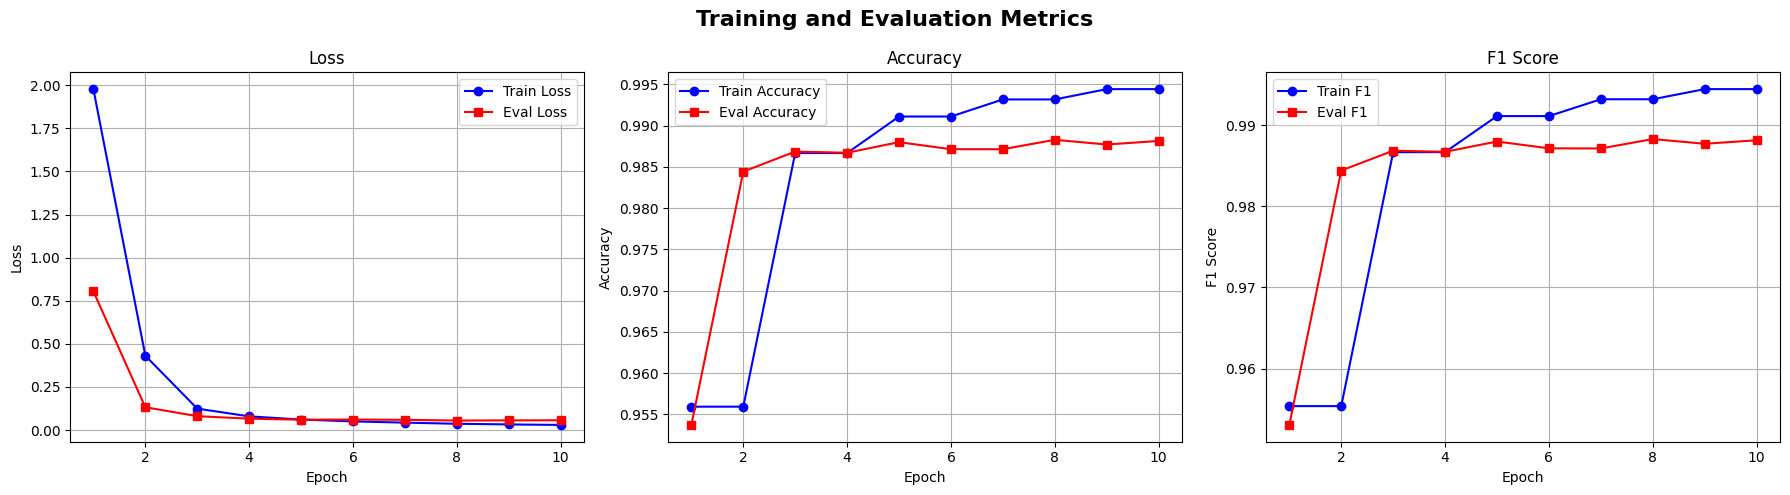

In [ ]:
plot_training_metrics(trainer)

In [ ]:
predictions = trainer.predict(test_dataset=tokenized_dataset["test"])

# Unpack the results
logits = predictions.predictions
labels = predictions.label_ids
metrics = predictions.metrics

metrics

{'test_loss': 0.04676709696650505,
 'test_accuracy': 0.9901428571428571,
 'test_f1': 0.9901411588296617,
 'test_runtime': 16.9983,
 'test_samples_per_second': 411.807,
 'test_steps_per_second': 51.476}

In [ ]:
from sklearn.metrics import classification_report

# Convert logits to predicted labels (by taking argmax)
predicted_labels = np.argmax(logits, axis=1)

# Generate classification report
report = classification_report(labels, predicted_labels)

# Print the classification report
print(report)

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       500
           1       0.99      0.99      0.99       500
           2       0.97      0.98      0.98       500
           3       1.00      1.00      1.00       500
           4       0.98      0.98      0.98       500
           5       0.99      1.00      0.99       500
           6       0.98      0.98      0.98       500
           7       1.00      0.99      0.99       500
           8       0.99      1.00      1.00       500
           9       0.99      1.00      1.00       500
          10       1.00      0.99      1.00       500
          11       0.99      1.00      1.00       500
          12       0.99      1.00      0.99       500
          13       0.99      0.99      0.99       500

    accuracy                           0.99      7000
   macro avg       0.99      0.99      0.99      7000
weighted avg       0.99      0.99      0.99      7000



- without weight decay

In [ ]:
training_args = transformers.TrainingArguments(
    num_train_epochs=20,
    per_device_train_batch_size=32,
    gradient_accumulation_steps=16,
    fp16=True,
    weight_decay=0.00,
    learning_rate=1e-5,
    logging_strategy="epoch",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    output_dir="outputs",
    optim="adamw_bnb_8bit",
    load_best_model_at_end=True,
    dataloader_num_workers=2,
    metric_for_best_model="eval_loss",
    greater_is_better=False,  # Because lower loss is better
    report_to="none"  # Disable logging to external services like TensorBoard/WandB
)

trainer1 = transformers.Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3, early_stopping_threshold=0.00001)]
    )

# Add custom callback
trainer1.add_callback(CustomCallback(trainer1))

# Start training
trainer1.train()

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-23-09977ccb4ef8>:20: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer1 = transformers.Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.024700,0.840171,0.961571,0.961204
2,0.439100,0.128041,0.987000,0.986993
3,0.127300,0.074860,0.989143,0.989137
4,0.082800,0.064388,0.988143,0.988141
5,0.063700,0.060399,0.989143,0.989142
6,0.053000,0.056138,0.989143,0.989142
7,0.044600,0.052342,0.989429,0.989429
8,0.039300,0.052196,0.988571,0.988572
9,0.034300,0.049272,0.989857,0.989854
10,0.030700,0.052359,0.989143,0.989142


early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find 

TrainOutput(global_step=605, training_loss=0.26980163223487286, metrics={'train_runtime': 4311.7771, 'train_samples_per_second': 129.877, 'train_steps_per_second': 0.25, 'total_flos': 3.926570259466483e+16, 'train_loss': 0.26980163223487286, 'epoch': 11.0})

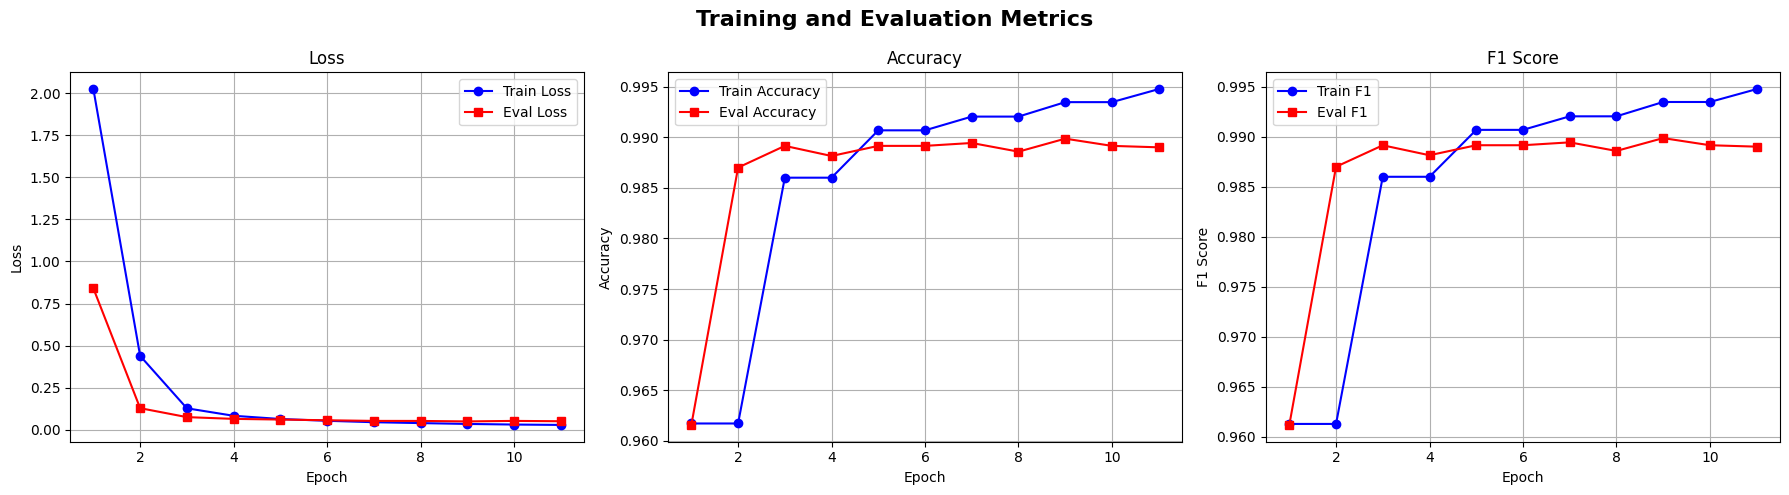

In [ ]:
plot_training_metrics(trainer1)

- This code **freezes the base model** (`AutoModelForSequenceClassification`) while training only the classification head.


In [ ]:
# Freeze the base model (DistilRoBERTa)
for param in model.roberta.parameters():
    param.requires_grad = False

# Count total parameters
total_params = sum(p.numel() for p in model.parameters())

# Count trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

training_args = transformers.TrainingArguments(
    num_train_epochs=40,
    per_device_train_batch_size=32,
    gradient_accumulation_steps=16,
    fp16=True,
    weight_decay=0.00,
    learning_rate=2e-4,
    logging_strategy="epoch",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    output_dir="outputsfreeze",
    optim="adamw_bnb_8bit",
    load_best_model_at_end=True,
    dataloader_num_workers=2,
    metric_for_best_model="eval_loss",
    greater_is_better=False,  # Because lower loss is better
    report_to="none"  # Disable logging to external services like TensorBoard/WandB
)

# Initialize Trainer with the modified model
trainer4 = transformers.Trainer(
    model=model,  # The instantiated model
    args=training_args,  # Training arguments
    train_dataset=tokenized_dataset["train"],  # Training dataset
    eval_dataset=tokenized_dataset["validation"],  # Validation dataset
    compute_metrics=compute_metrics,  # Function to compute metrics (accuracy & F1)
    data_collator=data_collator,  # Data collator to handle padding
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5, early_stopping_threshold=0.00003)]
)

# Add custom callback
trainer4.add_callback(CustomCallback(trainer4))
trainer4.train()

Total parameters: 82129166
Trainable parameters: 601358


/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-10-78828370509a>:34: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer4 = transformers.Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.416900,2.177630,0.842000,0.832649
2,1.792000,1.444017,0.912000,0.909828
3,1.126300,0.877184,0.928286,0.927162
4,0.721800,0.577950,0.942857,0.942413
5,0.513000,0.419368,0.945857,0.945573
6,0.398200,0.329969,0.950143,0.949880
7,0.327200,0.272446,0.954143,0.953907
8,0.283000,0.234637,0.956571,0.956443
9,0.251900,0.207863,0.958286,0.958072
10,0.229100,0.188243,0.960286,0.960129


early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find 

TrainOutput(global_step=2160, training_loss=0.31654529803329046, metrics={'train_runtime': 8275.1823, 'train_samples_per_second': 135.344, 'train_steps_per_second': 0.261, 'total_flos': 1.4007953036192294e+17, 'train_loss': 0.31654529803329046, 'epoch': 39.27428571428572})

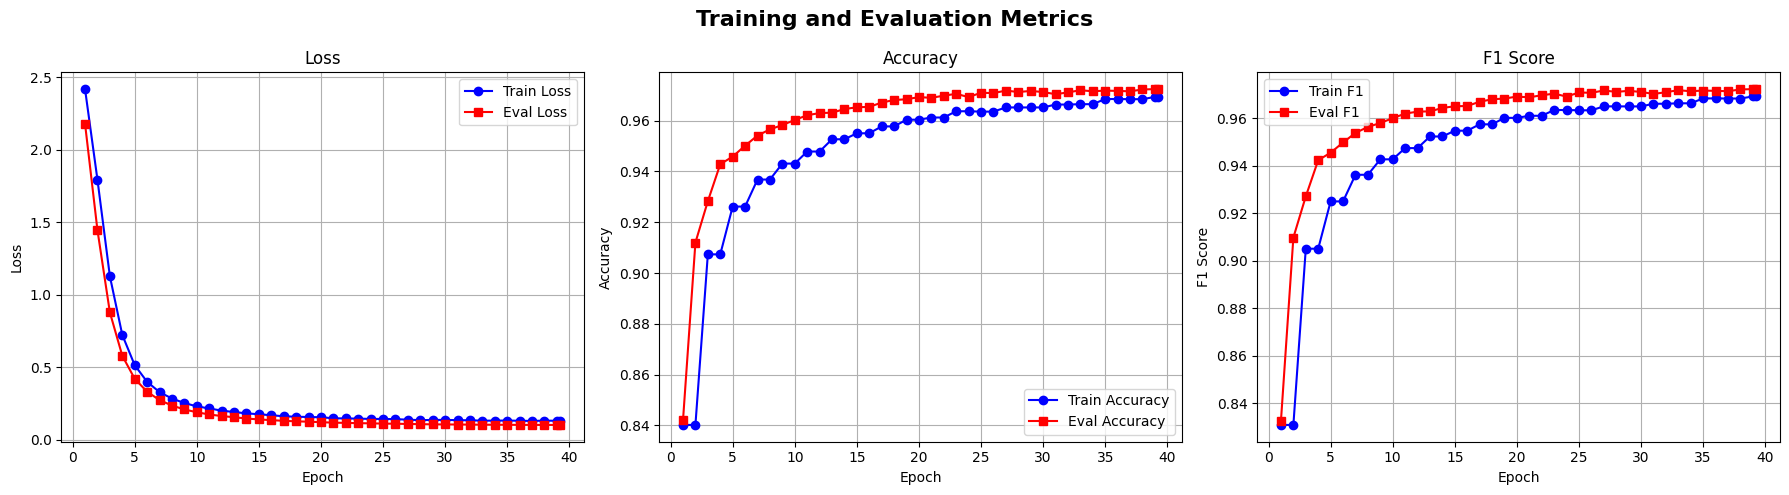

In [ ]:
plot_training_metrics(trainer4)

In [ ]:
predictions = trainer4.predict(test_dataset=tokenized_dataset["test"])

# Unpack the results
logits = predictions.predictions
labels = predictions.label_ids
metrics = predictions.metrics

metrics

{'test_loss': 0.10129152238368988,
 'test_accuracy': 0.9724285714285714,
 'test_f1': 0.9723894611259664,
 'test_runtime': 17.7378,
 'test_samples_per_second': 394.638,
 'test_steps_per_second': 49.33}

- Use LoRA to perform parameter efficient fine tuning (PEFT)

In [ ]:
from peft import LoraConfig, get_peft_model, TaskType

# Define a LoRA configuration
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # Task type
    r=8,                         # LoRA rank
    lora_alpha=32,               # Scaling factor
    lora_dropout=0.1,            # Dropout for LoRA
    target_modules=["query", "value"],  # Apply LoRA to specific transformer layers
)

# lora alpha, r have to do with the fact that we add a/r * ΔW
# Dropout zeroes out 0.1 of these values before adding them to the old weights

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

training_args = transformers.TrainingArguments(
    num_train_epochs=25,
    per_device_train_batch_size=32,
    gradient_accumulation_steps=16,
    fp16=True,
    weight_decay=0.00,
    learning_rate=5e-5,
    logging_strategy="epoch",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    output_dir="outputslora",
    optim="adamw_bnb_8bit",
    load_best_model_at_end=True,
    dataloader_num_workers=2,
    metric_for_best_model="eval_loss",
    greater_is_better=False,  # Because lower loss is better
    report_to="none"  # Disable logging to external services like TensorBoard/WandB
)

# Initialize Trainer with the modified model
trainer5 = transformers.Trainer(
    model=model,  # The instantiated model
    args=training_args,  # Training arguments
    train_dataset=tokenized_dataset["train"],  # Training dataset
    eval_dataset=tokenized_dataset["validation"],  # Validation dataset
    compute_metrics=compute_metrics,  # Function to compute metrics (accuracy & F1)
    data_collator=data_collator,  # Data collator to handle padding
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5, early_stopping_threshold=0.00003)]
)

# Add custom callback
trainer5.add_callback(CustomCallback(trainer5))
trainer5.train()

trainable params: 748,814 || all params: 82,877,980 || trainable%: 0.9035


/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-13-f2d29e62c9fb>:38: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer5 = transformers.Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.461400,1.860820,0.867714,0.857402
2,0.895600,0.202584,0.967429,0.967268
3,0.155400,0.077286,0.981143,0.981123
4,0.088400,0.059909,0.985000,0.984985
5,0.071700,0.053059,0.987000,0.986992
6,0.063100,0.049378,0.986714,0.986706
7,0.058300,0.048430,0.987000,0.986990
8,0.055400,0.046267,0.987571,0.987568
9,0.051700,0.045225,0.987857,0.987850
10,0.050400,0.044325,0.988143,0.988133


early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find 

TrainOutput(global_step=1320, training_loss=0.1892283892992771, metrics={'train_runtime': 8941.3257, 'train_samples_per_second': 78.288, 'train_steps_per_second': 0.151, 'total_flos': 8.420323373140224e+16, 'train_loss': 0.1892283892992771, 'epoch': 24.0})

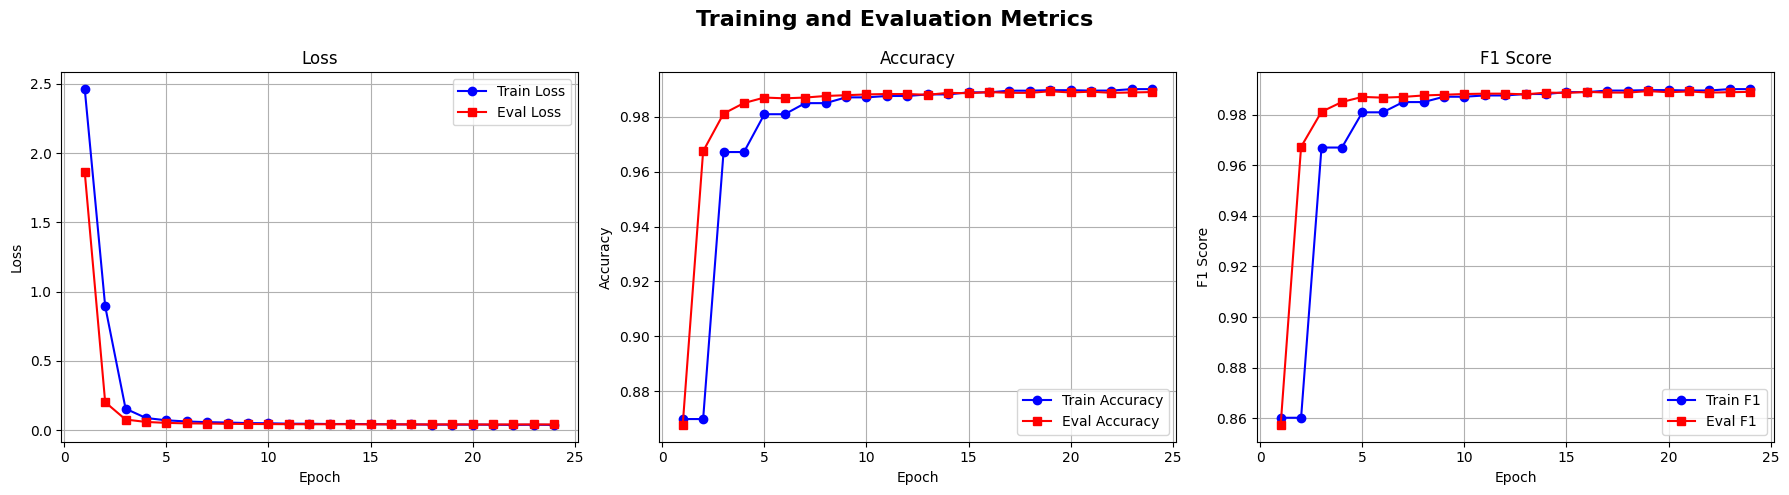

In [ ]:
plot_training_metrics(trainer5)

In [ ]:
predictions1 = trainer5.predict(test_dataset=tokenized_dataset["test"])

# Unpack the results
logits1 = predictions1.predictions
labels1 = predictions1.label_ids
metrics1 = predictions1.metrics

metrics1

{'test_loss': 0.03979351744055748,
 'test_accuracy': 0.9905714285714285,
 'test_f1': 0.9905597469321767,
 'test_runtime': 18.0398,
 'test_samples_per_second': 388.03,
 'test_steps_per_second': 48.504}

In [ ]:
from sklearn.metrics import classification_report

# Convert logits to predicted labels (by taking argmax)
predicted_labels1 = np.argmax(logits1, axis=1)

# Generate classification report
report1 = classification_report(labels1, predicted_labels1)

# Print the classification report
print(report1)

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       500
           1       0.98      0.99      0.99       500
           2       0.98      0.98      0.98       500
           3       0.99      1.00      1.00       500
           4       0.99      0.98      0.98       500
           5       0.99      1.00      1.00       500
           6       0.98      0.98      0.98       500
           7       0.99      1.00      1.00       500
           8       1.00      1.00      1.00       500
           9       1.00      0.99      0.99       500
          10       0.99      0.99      0.99       500
          11       1.00      0.99      0.99       500
          12       0.99      0.99      0.99       500
          13       0.99      0.99      0.99       500

    accuracy                           0.99      7000
   macro avg       0.99      0.99      0.99      7000
weighted avg       0.99      0.99      0.99      7000



### Custom Model with Dropout and Max Pooling

This custom model uses `distilroberta-base` as the backbone for sequence classification, enhanced with dropout and max pooling:

- **Backbone**: Utilizes the pre-trained `distilroberta-base` from Hugging Face.
- **Max Pooling**: Applies max pooling across the sequence dimension to capture the most significant features from the sequence.
- **Dropout**: Includes a dropout layer (default 0.5) for regularization to prevent overfitting.
- **Classifier**: A fully connected layer that maps the pooled output to class logits.
- **Loss Function**: Uses `CrossEntropyLoss` for multi-class classification during training.


In [14]:
import torch
import torch.nn as nn
import transformers
import torch.nn.functional as F

class CustomModelwithDropoutAndMaxPooling(nn.Module):
    def __init__(self, model_name, num_labels, dropout_rate=0.5):
        super(CustomModelwithDropoutAndMaxPooling, self).__init__()
        self.backbone = transformers.AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(self.backbone.config.hidden_size, num_labels)
        self.loss_fn = nn.CrossEntropyLoss()  # Define loss function

    def forward(self, input_ids, attention_mask, labels=None):  # ✅ Accept labels
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state
        pooled_output, _ = torch.max(sequence_output, dim=1)
        x = self.dropout(pooled_output)
        logits = self.classifier(x)

        if labels is not None:  # ✅ Compute loss if labels are provided
            loss = self.loss_fn(logits, labels)
            return {"loss": loss, "logits": logits}  # ✅ Trainer expects this format

        return {"logits": logits}  # ✅ If no labels, just return logits


# Initialize the model
model_name = "distilroberta-base"
num_labels = 14
model2 = CustomModelwithDropoutAndMaxPooling(model_name=model_name, num_labels=num_labels)

# Count model parameters
total_params = sum(p.numel() for p in model2.parameters())
trainable_params = sum(p.numel() for p in model2.parameters() if p.requires_grad)

# Print parameter details
print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

training_args = transformers.TrainingArguments(
    num_train_epochs=25,
    per_device_train_batch_size=32,
    gradient_accumulation_steps=16,
    fp16=True,
    weight_decay=0.00,
    learning_rate=1e-5,
    logging_strategy="epoch",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    output_dir="outputs1",
    optim="adamw_bnb_8bit",
    load_best_model_at_end=True,
    dataloader_num_workers=2,
    metric_for_best_model="eval_loss",
    greater_is_better=False,  # Because lower loss is better
    report_to="none"  # Disable logging to external services like TensorBoard/WandB
)

# Initialize Trainer with the modified model
trainer2 = transformers.Trainer(
    model=model2,  # The instantiated model
    args=training_args,  # Training arguments
    train_dataset=tokenized_dataset["train"],  # Training dataset
    eval_dataset=tokenized_dataset["validation"],  # Validation dataset
    compute_metrics=compute_metrics,  # Function to compute metrics (accuracy & F1)
    data_collator=data_collator,  # Data collator to handle padding
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5, early_stopping_threshold=0.00003)]
)

# Add custom callback
trainer2.add_callback(CustomCallback(trainer2))
trainer2.train()

Total parameters: 82129166
Trainable parameters: 82129166


/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-14-820ba5c2492f>:61: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer2 = transformers.Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.282600,0.898173,0.903286,0.898149
2,0.382100,0.066126,0.986429,0.986428
3,0.075000,0.048471,0.987429,0.987428


early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.282600,0.898173,0.903286,0.898149
2,0.382100,0.066126,0.986429,0.986428
3,0.075000,0.048471,0.987429,0.987428
4,0.053100,0.047126,0.987000,0.986989
5,0.042800,0.042259,0.988714,0.988714
6,0.036000,0.041897,0.989143,0.989138
7,0.030600,0.043510,0.989714,0.989723
8,0.027100,0.042702,0.990000,0.990004
9,0.023300,0.041641,0.990286,0.990291
10,0.021000,0.042917,0.989429,0.989434


early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find 

TrainOutput(global_step=770, training_loss=0.2171420717394197, metrics={'train_runtime': 4387.6009, 'train_samples_per_second': 159.54, 'train_steps_per_second': 0.308, 'total_flos': 0.0, 'train_loss': 0.2171420717394197, 'epoch': 14.0})

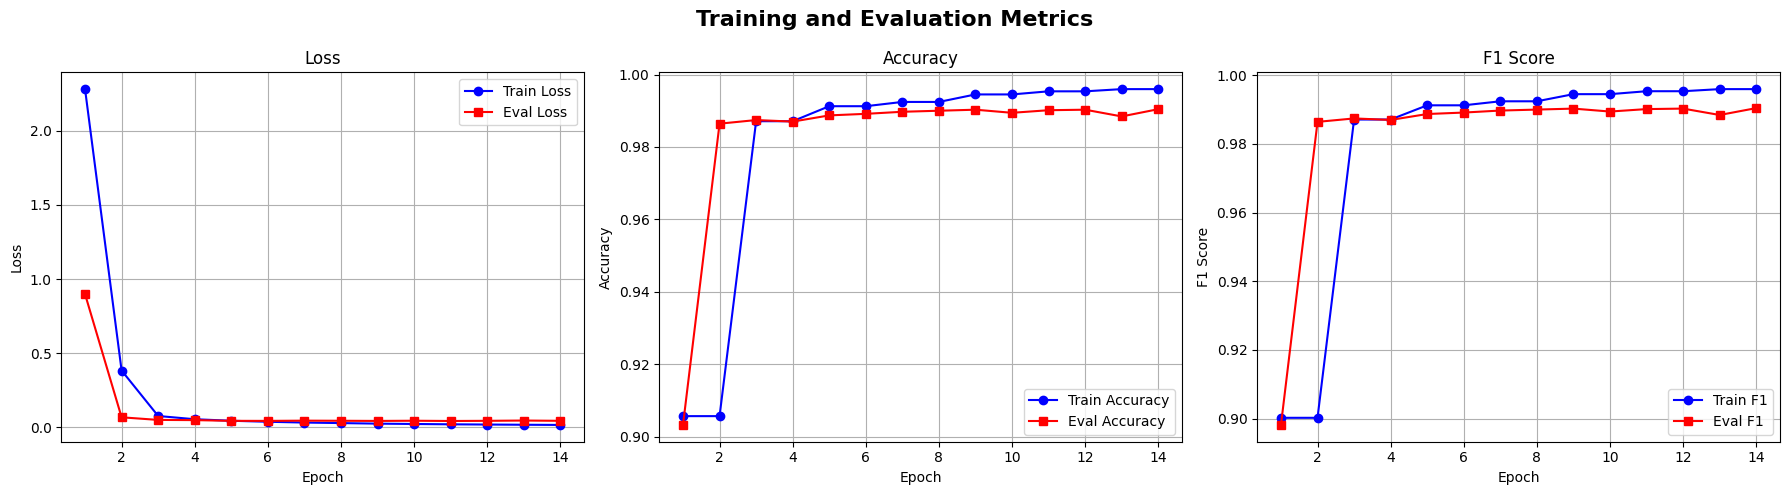

In [15]:
plot_training_metrics(trainer2)

In [16]:
predictions = trainer2.predict(test_dataset=tokenized_dataset["test"])

# Unpack the results
logits = predictions.predictions
labels = predictions.label_ids
metrics = predictions.metrics

metrics

{'test_loss': 0.051055241376161575,
 'test_accuracy': 0.9885714285714285,
 'test_f1': 0.9885665298030398,
 'test_runtime': 17.3659,
 'test_samples_per_second': 403.089,
 'test_steps_per_second': 50.386}

In [17]:
from sklearn.metrics import classification_report

# Convert logits to predicted labels (by taking argmax)
predicted_labels = np.argmax(logits, axis=1)

# Generate classification report
report = classification_report(labels, predicted_labels)

# Print the classification report
print(report)

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       500
           1       0.99      0.98      0.98       500
           2       0.98      0.99      0.99       500
           3       1.00      0.99      0.99       500
           4       0.98      0.99      0.98       500
           5       1.00      1.00      1.00       500
           6       0.97      0.98      0.98       500
           7       0.99      1.00      1.00       500
           8       1.00      1.00      1.00       500
           9       0.99      0.99      0.99       500
          10       0.99      0.99      0.99       500
          11       1.00      0.99      0.99       500
          12       0.99      0.99      0.99       500
          13       0.99      0.99      0.99       500

    accuracy                           0.99      7000
   macro avg       0.99      0.99      0.99      7000
weighted avg       0.99      0.99      0.99      7000



### Custom Model with Attention

This custom model uses the `distilroberta-base` as the backbone for sequence classification. It incorporates the following components:

- **Backbone**: Utilizes the pre-trained `distilroberta-base` from Hugging Face.
- **Self-Attention**: Applies a custom attention mechanism to compute attention scores for each token and aggregates them to create a context vector.
- **Dropout**: Includes a dropout layer (default 0.5) for regularization.
- **Classifier**: A fully connected layer that maps the context vector to class logits.
- **Loss Function**: Uses `CrossEntropyLoss` for multi-class classification during training.

In [24]:
class CustomModelWithAttention(nn.Module):
    def __init__(self, model_name, num_labels, dropout_rate=0.5):
        super(CustomModelWithAttention, self).__init__()
        self.backbone = transformers.AutoModel.from_pretrained(model_name)
        hidden_size = self.backbone.config.hidden_size

        # Self-Attention Mechanism
        self.attention = nn.Linear(hidden_size, 1)  # Attention scores for each token
        self.softmax = nn.Softmax(dim=1)  # Softmax over token dimension

        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(hidden_size, num_labels)  # Final classifier
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state  # Shape: (batch_size, seq_len, hidden_size)

        # Compute attention scores
        attn_scores = self.attention(sequence_output)  # Shape: (batch_size, seq_len, 1)
        attn_weights = self.softmax(attn_scores)  # Shape: (batch_size, seq_len, 1)

        # Apply attention weights
        context_vector = torch.sum(attn_weights * sequence_output, dim=1)  # Shape: (batch_size, hidden_size)

        x = self.dropout(context_vector)
        logits = self.classifier(x)

        if labels is not None:
            loss = self.loss_fn(logits, labels)
            return {"loss": loss, "logits": logits}

        return {"logits": logits}

# Initialize the model
model_name = "distilroberta-base"
num_labels = 14
model3 = CustomModelWithAttention(model_name=model_name, num_labels=num_labels)

# Count model parameters
total_params = sum(p.numel() for p in model3.parameters())
trainable_params = sum(p.numel() for p in model3.parameters() if p.requires_grad)

# Print parameter details
print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

training_args = transformers.TrainingArguments(
    num_train_epochs=25,
    per_device_train_batch_size=32,
    gradient_accumulation_steps=16,
    fp16=True,
    weight_decay=0.00,
    learning_rate=1e-5,
    logging_strategy="epoch",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    output_dir="outputs",
    optim="adamw_bnb_8bit",
    load_best_model_at_end=True,
    dataloader_num_workers=2,
    metric_for_best_model="eval_loss",
    greater_is_better=False,  # Because lower loss is better
    report_to="none"  # Disable logging to external services like TensorBoard/WandB
)

# Initialize Trainer with the modified model
trainer3 = transformers.Trainer(
    model=model3,  # The instantiated model
    args=training_args,  # Training arguments
    train_dataset=tokenized_dataset["train"],  # Training dataset
    eval_dataset=tokenized_dataset["validation"],  # Validation dataset
    compute_metrics=compute_metrics,  # Function to compute metrics (accuracy & F1)
    data_collator=data_collator,  # Data collator to handle padding
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3, early_stopping_threshold=0.00003)]
)

# Add custom callback
trainer3.add_callback(CustomCallback(trainer3))
trainer3.train()

Total parameters: 82129935
Trainable parameters: 82129935


/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-24-20c6e712e5dc>:68: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer3 = transformers.Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.826900,0.388909,0.978429,0.978405
2,0.176500,0.052167,0.988714,0.988712
3,0.059000,0.044941,0.988571,0.988568
4,0.044900,0.043333,0.988571,0.988568
5,0.037300,0.042007,0.989000,0.988998
6,0.030800,0.041678,0.989714,0.989713
7,0.026700,0.042076,0.989143,0.989147
8,0.023200,0.041642,0.990286,0.990285
9,0.020300,0.044619,0.989000,0.988992
10,0.017600,0.043188,0.990000,0.990005


early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find eval_loss so early stopping is disabled
early stopping required metric_for_best_model, but did not find 

TrainOutput(global_step=550, training_loss=0.22632483124732972, metrics={'train_runtime': 3282.5761, 'train_samples_per_second': 213.247, 'train_steps_per_second': 0.411, 'total_flos': 0.0, 'train_loss': 0.22632483124732972, 'epoch': 10.0})

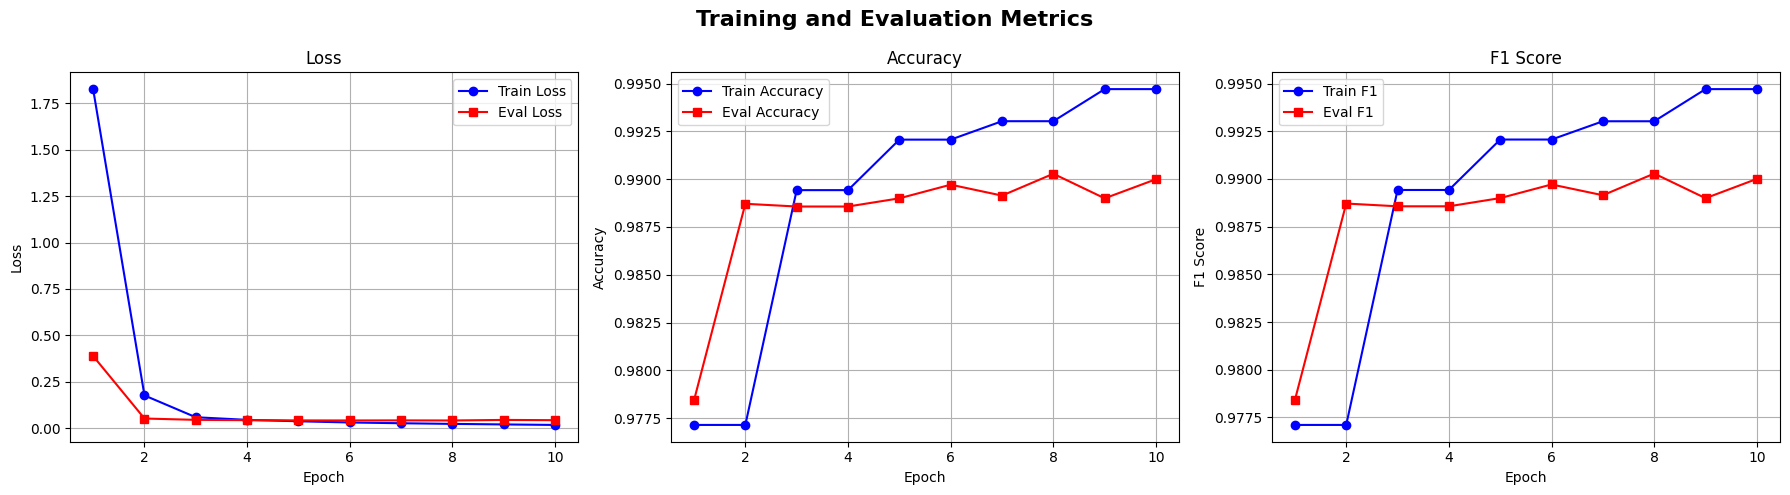

In [25]:
plot_training_metrics(trainer3)

In [26]:
predictions = trainer3.predict(test_dataset=tokenized_dataset["test"])

# Unpack the results
logits = predictions.predictions
labels = predictions.label_ids
metrics = predictions.metrics

metrics

{'test_loss': 0.04824567586183548,
 'test_accuracy': 0.9888571428571429,
 'test_f1': 0.9888602337110007,
 'test_runtime': 17.1818,
 'test_samples_per_second': 407.407,
 'test_steps_per_second': 50.926}

In [28]:
from sklearn.metrics import classification_report

# Convert logits to predicted labels (by taking argmax)
predicted_labels = np.argmax(logits, axis=1)

# Generate classification report
report = classification_report(labels, predicted_labels)

# Print the classification report
print(report)

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       500
           1       0.99      0.98      0.98       500
           2       0.98      0.98      0.98       500
           3       1.00      0.99      0.99       500
           4       0.98      0.99      0.98       500
           5       1.00      1.00      1.00       500
           6       0.98      0.98      0.98       500
           7       0.99      1.00      1.00       500
           8       1.00      1.00      1.00       500
           9       1.00      0.99      0.99       500
          10       0.99      0.99      0.99       500
          11       1.00      0.99      0.99       500
          12       0.99      0.99      0.99       500
          13       0.99      0.99      0.99       500

    accuracy                           0.99      7000
   macro avg       0.99      0.99      0.99      7000
weighted avg       0.99      0.99      0.99      7000



In the following table, the results across all models (Transformers and baselines) are presented. As we can see, the Transformers **outperform the baselines**:

| **Metric**         | **Transformer** | **CNN**  | **RNN**  | **MLP**  | **Logistic Regression** |
|--------------------|:---------------:|:--------:|:--------:|:--------:|:-----------------------:|
| Macro Precision    | 0.9906          | 0.9773   | 0.9770   | 0.9379   | 0.9373                  |
| Macro Recall       | 0.9906          | 0.9774   | 0.9770   | 0.9378   | 0.9373                  |
| Macro F1-score     | 0.9906          | 0.9773   | 0.9771   | 0.9378   | 0.9372                  |
| Best Val.loss      | 0.04176         | 0.07291  | 0.07262  | 0.19186  | -                       |
| Test Accuracy      | 0.9906          | 0.9906   | 0.9906   | 0.9906   | 0.9906                  |
| Test F1            | 0.9906          | 0.9906   | 0.9906   | 0.9906   | 0.9906                  |
